# Gathering Relevant Data

In [1]:
# Dependencies
library(here) # working directory
library(ggplot2)
library(dplyr)
library(leaps)
library(tidyr)
library(tidyverse)
library(corrplot)
library(car)

here() starts at /Users/amberteetsel/MSDS/STAT_5010/opioid-crisis


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.2.0
✔ lubridate 1.9.5     ✔ stringr   1.6.0
✔ purrr     1.2.1     ✔ tibble    3.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:purrr’:

    some


The following object is masked from ‘package:dplyr’:

    recode




## NCHS - Drug Poisoning Mortality by State

In [ ]:
# Load Data
nchs_df <- read.csv(here("data", "NCHS_Mortality_Clean.csv"))

# Keep relevant columns
nchs_df = nchs_df[, c("state", "year", "sex", "age_group", "age_group_detail",
                      "race", "population", "deaths", "death_rate")]
head(nchs_df)
dim(nchs_df)

,state,year,sex,age_group,age_group_detail,race,population,deaths,death_rate
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>
1,Alabama,1999,Both Sexes,All Ages,All Ages,All Races,4430143,169,3.8521
2,Alabama,2000,Both Sexes,All Ages,All Ages,All Races,4447100,197,4.4857
3,Alabama,2001,Both Sexes,All Ages,All Ages,All Races,4467634,216,4.8915
4,Alabama,2002,Both Sexes,All Ages,All Ages,All Races,4480089,211,4.7619
5,Alabama,2003,Both Sexes,All Ages,All Ages,All Races,4503491,197,4.4333
6,Alabama,2004,Both Sexes,All Ages,All Ages,All Races,4530729,283,6.3542


[1] 2862    9

In [3]:
# Filter for State-Level Data
nchs_state <- nchs_df |>
  filter(
    state != "United States",
    sex == "Both Sexes",
    age_group == "All Ages",
    race == "All Races",
    year >= 2000,
    state != "District of Columbia"
  )
nchs_state <- nchs_state[, c("state", "year", "deaths", "death_rate")]

# Add state abbr
nchs_state <- nchs_state |>
  mutate(
    state_abbr = state.abb[match(toupper(state), toupper(state.name))]
  )
nchs_state = nchs_state[, c("state_abbr", "year", "deaths", "death_rate")] |>
  rename(state = state_abbr)

# Display final NCHS State DataFrame
head(nchs_state)

,state,year,deaths,death_rate
,<chr>,<int>,<int>,<dbl>
1,AL,2000,197,4.4857
2,AL,2001,216,4.8915
3,AL,2002,211,4.7619
4,AL,2003,197,4.4333
5,AL,2004,283,6.3542
6,AL,2005,283,6.3330


## DEA: Retail Drug Transactions

In [4]:
# Load Data
dea_df <- read.csv(here("data", "DEA_Clean.csv"))
dea_df <- dea_df |> filter(state != "DC")
dea_state <- dea_df

# Display final DEA State DataFrame
head(dea_state)

,state,year,hydro_gms,oxy_gms,fent_gms
,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,AK,2000,27018.40,74395.72,613.2600
2,AK,2001,32213.77,110300.16,613.2600
3,AK,2002,35524.00,106095.60,722.8675
4,AK,2003,38834.23,101891.03,832.4750
5,AK,2004,42144.46,97686.46,942.0825
6,AK,2005,45454.69,93481.90,1051.6900


## University of Kentucky Center for Poverty Research (UKCPR) National Welfare Data

In [5]:
uk_raw <- read.csv(here("data", "UKCPR_Raw.csv"))
uk_raw <- uk_raw |> filter(state_name != "DC")

uk_raw <- uk_raw |>
  filter(
    year >= 2000 & year <= 2016,
  )

uk_raw <- uk_raw[, c("state_name", "year", "Population", "Unemployment",
                     "Number.of.Poor..thousands.", "Gross.State.Product",
                     "Food.Stamp.SNAP.Recipients", "Medicaid.beneficiaries",
                     "State.Minimum.Wage")]

uk_raw <- uk_raw |>
  rename(
    state = state_name,
    year = year,
    pop = Population,
    unempl_pop = Unemployment,
    poverty_pop = Number.of.Poor..thousands.,
    gsp = Gross.State.Product,
    snap_pop = Food.Stamp.SNAP.Recipients,
    medicaid_pop = Medicaid.beneficiaries,
    min_wage = State.Minimum.Wage
  )

head(uk_raw)

,state,year,pop,unempl_pop,poverty_pop,gsp,snap_pop,medicaid_pop,min_wage
,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>
1,AL,2000,4452173,97629,583,120132.9,396057,564926,5.15
2,AK,2000,627963,20365,47,26815.8,37524,83161,5.65
3,AZ,2000,5160586,99302,607,164609.9,259006,483993,5.15
4,AR,2000,2678588,53606,436,68740.4,246572,392018,5.15
5,CA,2000,33987977,834629,4294,1366166.5,1831698,6168816,6.25
6,CO,2000,4326921,65107,425,180693.3,155948,278969,5.15


In [6]:
# Calculate Rates for State-Level Data
uk_state <- uk_raw |>
  group_by(year) |>
  mutate(
    unempl_rate = (unempl_pop / pop) * 100,
    poverty_rate = (poverty_pop*1000 / pop) * 100,
    snap_rate = (snap_pop / pop) * 100,
    medicaid_rate = (medicaid_pop / pop) * 100,
    gsp_per_cap = (gsp * 1000000) / pop,
    min_wage = min_wage
  ) |>
  filter(state != "DC")

uk_state <- uk_state[, c("state", "year", "pop", "unempl_rate",
                         "poverty_rate", "snap_rate", "medicaid_rate",
                         "gsp_per_cap", "min_wage")]

head(uk_state)

state,year,pop,unempl_rate,poverty_rate,snap_rate,medicaid_rate,gsp_per_cap,min_wage
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AL,2000,4452173,2.192839,13.094729,8.895813,12.688770,26982.98,5.15
AK,2000,627963,3.243025,7.484517,5.975511,13.242978,42702.83,5.65
AZ,2000,5160586,1.924239,11.762230,5.018926,9.378644,31897.52,5.15
AR,2000,2678588,2.001278,16.277233,9.205298,14.635248,25662.92,5.15
CA,2000,33987977,2.455660,12.633879,5.389253,18.149995,40195.58,6.25
CO,2000,4326921,1.504696,9.822227,3.604133,6.447287,41760.25,5.15


In [7]:
# Join Data on Year, State
df_final_state = nchs_state |>
  left_join(dea_state, by = c("year", "state")) |>
  left_join(uk_state, by = c("year", "state"))

# Calculate Drug Supply per 100k Population
df_final_state <- df_final_state |>
  mutate(
    hydro_gms = (hydro_gms / pop) * 100000,
    oxy_gms = (oxy_gms / pop) * 100000,
    fent_gms = (fent_gms / pop) * 100000
  )

# Separate for Negative Binomial Regression
df_br <- df_final_state

df_final_state <- df_final_state[,
                                 c("year", "state", "pop",
                                   "hydro_gms", "oxy_gms", "fent_gms",
                                   "unempl_rate", "poverty_rate", "snap_rate", 
                                   "medicaid_rate", "gsp_per_cap", "min_wage",
                                   "deaths", "death_rate")]

# Display Final State-Level DataFrame
head(df_final_state)

,year,state,pop,hydro_gms,oxy_gms,fent_gms,unempl_rate,poverty_rate,snap_rate,medicaid_rate,gsp_per_cap,min_wage,deaths,death_rate
,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
1,2000,AL,4452173,10652.63,6716.904,62.74487,2.192839,13.09473,8.895813,12.68877,26982.98,5.15,197,4.4857
2,2001,AL,4467634,11269.21,7735.814,62.52773,2.428959,15.57872,9.206036,15.08646,27539.25,5.15,216,4.8915
3,2002,AL,4480089,12882.26,8232.095,83.42898,2.773204,14.28543,9.900406,16.45260,28597.07,5.15,211,4.7619
4,2003,AL,4503491,14451.14,8704.415,103.96102,2.830982,14.72191,10.482224,16.60621,29747.88,5.15,197,4.4333
5,2004,AL,4530729,15990.25,9164.086,124.17555,2.683211,16.84056,10.982581,17.26546,32420.10,5.15,283,6.3542
6,2005,AL,4569805,17465.61,9593.347,143.77506,2.105867,16.41208,12.223629,17.69277,34225.38,5.15,283,6.3330


## Scaling & Transforming

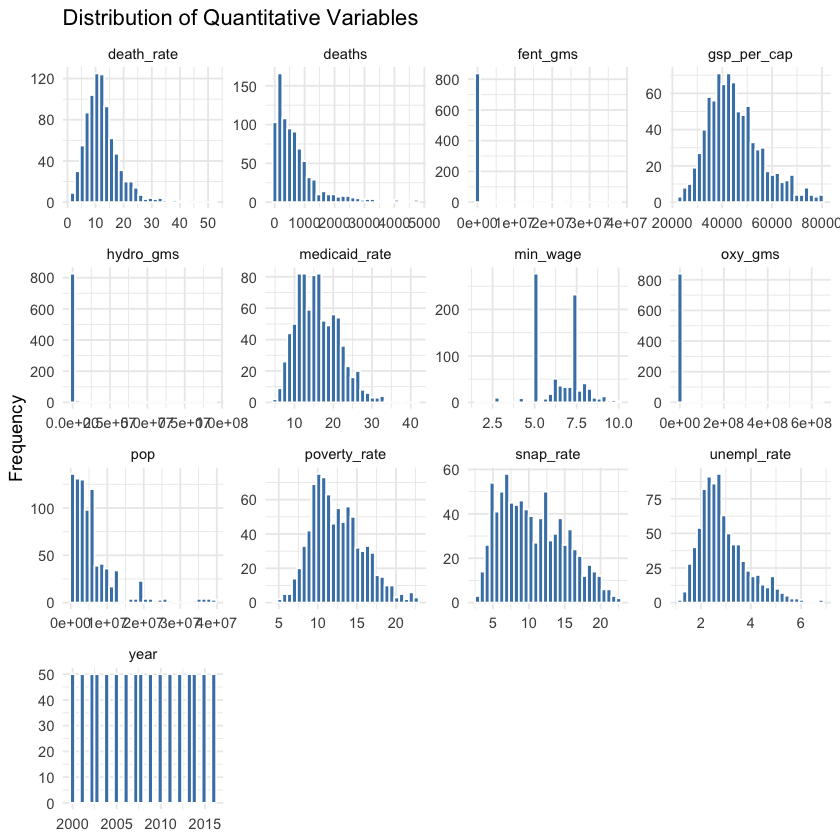

In [8]:
# Check distributions
# Histograms for Numeric Variables
df_final_state |>
  select(where(is.numeric)) |>
  pivot_longer(cols = everything(),
               names_to = "variable",
               values_to = "value") |>
  ggplot(aes(x = value)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  facet_wrap(~variable, scales = "free") +
  theme_minimal() +
  labs(title = "Distribution of Quantitative Variables",
       x = NULL,
       y = "Frequency")

In [9]:
# Apply Log Transformations to Drug Supply Data and Other Skewed Distributions
df_final_state <- df_final_state |>
  mutate(
    log_hydro = log(hydro_gms + 1),
    log_oxy = log(oxy_gms + 1),
    log_fent = log(fent_gms + 1),
    log_death_rate = log(death_rate + 1)
  )

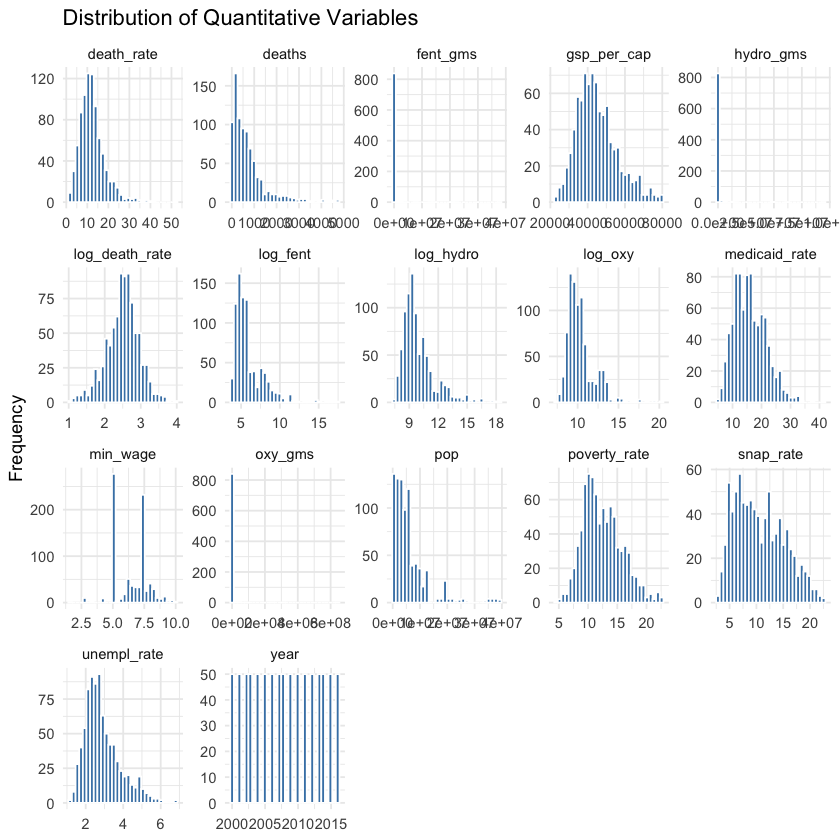

In [10]:
# Check distributions post log-transformation
# Histograms for Numeric Variables
df_final_state |>
  select(where(is.numeric)) |>
  pivot_longer(cols = everything(),
               names_to = "variable",
               values_to = "value") |>
  ggplot(aes(x = value)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  facet_wrap(~variable, scales = "free") +
  theme_minimal() +
  labs(title = "Distribution of Quantitative Variables",
       x = NULL,
       y = "Frequency")

In [11]:
head(df_final_state)

,year,state,pop,hydro_gms,oxy_gms,fent_gms,unempl_rate,poverty_rate,snap_rate,medicaid_rate,gsp_per_cap,min_wage,deaths,death_rate,log_hydro,log_oxy,log_fent,log_death_rate
,<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2000,AL,4452173,10652.63,6716.904,62.74487,2.192839,13.09473,8.895813,12.68877,26982.98,5.15,197,4.4857,9.273656,8.812531,4.154889,1.702145
2,2001,AL,4467634,11269.21,7735.814,62.52773,2.428959,15.57872,9.206036,15.08646,27539.25,5.15,216,4.8915,9.329919,8.953745,4.151476,1.773511
3,2002,AL,4480089,12882.26,8232.095,83.42898,2.773204,14.28543,9.900406,16.45260,28597.07,5.15,211,4.7619,9.463684,9.015917,4.435911,1.751267
4,2003,AL,4503491,14451.14,8704.415,103.96102,2.830982,14.72191,10.482224,16.60621,29747.88,5.15,197,4.4333,9.578598,9.071701,4.653589,1.692547
5,2004,AL,4530729,15990.25,9164.086,124.17555,2.683211,16.84056,10.982581,17.26546,32420.10,5.15,283,6.3542,9.679797,9.123157,4.829717,1.995272
6,2005,AL,4569805,17465.61,9593.347,143.77506,2.105867,16.41208,12.223629,17.69277,34225.38,5.15,283,6.3330,9.768046,9.168929,4.975181,1.992385


In [12]:
# Export final dataset (state level)
write.csv(df_final_state, here("data", "death_rate.csv"), row.names = FALSE)

In [13]:
# Scale
df_state_scaled <- df_final_state |>
  mutate(across(where(is.numeric) & !year, ~as.numeric(scale(.x))))

head(df_state_scaled)
summary(df_state_scaled)

,year,state,pop,hydro_gms,oxy_gms,fent_gms,unempl_rate,poverty_rate,snap_rate,medicaid_rate,gsp_per_cap,min_wage,deaths,death_rate,log_hydro,log_oxy,log_fent,log_death_rate
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2000,AL,-0.2396840,-0.1037009,-0.07198984,-0.08602873,-0.73962867,0.1942059,-0.38573312,-0.62386327,-1.6618041,-1.026754,-0.6642165,-1.308400,-0.3974345,-0.9192862,-0.9234053,-1.787006
2,2001,AL,-0.2373706,-0.1035686,-0.07195101,-0.08602885,-0.49287538,0.9488591,-0.31689900,-0.18631157,-1.6108019,-1.026754,-0.6401894,-1.241686,-0.3637661,-0.8364945,-0.9250998,-1.627562
3,2002,AL,-0.2355071,-0.1032225,-0.07193209,-0.08601729,-0.13312766,0.5559496,-0.16282797,0.06299210,-1.5138153,-1.026754,-0.6465123,-1.262992,-0.2837199,-0.8000439,-0.7838532,-1.677258
4,2003,AL,-0.2320056,-0.1028859,-0.07191409,-0.08600594,-0.07274793,0.6885560,-0.03373072,0.09102397,-1.4083021,-1.026754,-0.6642165,-1.317015,-0.2149542,-0.7673390,-0.6757568,-1.808450
5,2004,AL,-0.2279301,-0.1025557,-0.07189656,-0.08599476,-0.22717372,1.3322157,0.07729171,0.21132943,-1.1632969,-1.026754,-0.5554622,-1.001213,-0.1543956,-0.7371711,-0.5882937,-1.132110
6,2005,AL,-0.2220834,-0.1022392,-0.07188020,-0.08598392,-0.83051811,1.2020409,0.35266288,0.28930908,-0.9977787,-1.026754,-0.5554622,-1.004699,-0.1015865,-0.7103351,-0.5160579,-1.138560


      year         state                pop            hydro_gms       
 Min.   :2000   Length:850         Min.   :-0.8319   Min.   :-0.10563  
 1st Qu.:2004   Class :character   1st Qu.:-0.6369   1st Qu.:-0.10452  
 Median :2008   Mode  :character   Median :-0.2592   Median :-0.10325  
 Mean   :2008                      Mean   : 0.0000   Mean   : 0.00000  
 3rd Qu.:2012                      3rd Qu.: 0.1140   3rd Qu.:-0.09761  
 Max.   :2016                      Max.   : 4.9545   Max.   :20.15423  
    oxy_gms            fent_gms         unempl_rate       poverty_rate    
 Min.   :-0.07219   Min.   :-0.08604   Min.   :-1.8114   Min.   :-2.4119  
 1st Qu.:-0.07186   1st Qu.:-0.08600   1st Qu.:-0.7015   1st Qu.:-0.7649  
 Median :-0.07143   Median :-0.08594   Median :-0.2092   Median :-0.1545  
 Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.:-0.07013   3rd Qu.:-0.08564   3rd Qu.: 0.5115   3rd Qu.: 0.6633  
 Max.   :24.43590   Max.   :20.80833   Max.   

In [14]:
# Export final dataset (state level, scaled)
write.csv(df_state_scaled, here("data", "death_rate_scaled.csv"),
          row.names = FALSE)

In [15]:
# Custom Scaling/Tranforming for Negative Binomial Regression
df_br <- df_br |>
  mutate(
    log_pop = log(df_br$pop + 1),
    log_hydro = log(hydro_gms + 1),
    log_oxy = log(oxy_gms + 1),
    log_fent = log(fent_gms + 1),
    log_death_rate = log(death_rate + 1)
  )

# Scaling: Z-Score
df_br_scaled <- df_br |>
  mutate(across(where(is.numeric) & !year & !deaths & !log_pop,
                ~as.numeric(scale(.x))))

head(df_br)

,state,year,deaths,death_rate,hydro_gms,oxy_gms,fent_gms,pop,unempl_rate,poverty_rate,snap_rate,medicaid_rate,gsp_per_cap,min_wage,log_pop,log_hydro,log_oxy,log_fent,log_death_rate
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AL,2000,197,4.4857,10652.63,6716.904,62.74487,4452173,2.192839,13.09473,8.895813,12.68877,26982.98,5.15,15.30890,9.273656,8.812531,4.154889,1.702145
2,AL,2001,216,4.8915,11269.21,7735.814,62.52773,4467634,2.428959,15.57872,9.206036,15.08646,27539.25,5.15,15.31237,9.329919,8.953745,4.151476,1.773511
3,AL,2002,211,4.7619,12882.26,8232.095,83.42898,4480089,2.773204,14.28543,9.900406,16.45260,28597.07,5.15,15.31515,9.463684,9.015917,4.435911,1.751267
4,AL,2003,197,4.4333,14451.14,8704.415,103.96102,4503491,2.830982,14.72191,10.482224,16.60621,29747.88,5.15,15.32036,9.578598,9.071701,4.653589,1.692547
5,AL,2004,283,6.3542,15990.25,9164.086,124.17555,4530729,2.683211,16.84056,10.982581,17.26546,32420.10,5.15,15.32639,9.679797,9.123157,4.829717,1.995272
6,AL,2005,283,6.3330,17465.61,9593.347,143.77506,4569805,2.105867,16.41208,12.223629,17.69277,34225.38,5.15,15.33498,9.768046,9.168929,4.975181,1.992385


In [16]:
# Save dataset for Negative Binomial Regression
write.csv(df_br_scaled, here("data", "death_rate_nb.csv"), row.names = FALSE)